# House Prices Prediction using XGBOOST,LGBM ,Ridge, Lasso, ElasticNet
#####
##### This notebook walks you through training a predictive model for house prices using XGBoost,LGBM ,Ridge, Lasso, ElasticNet.
##### we explore data cleaning , and feature engineering ,encoding strategies to improve eccuracy.
##### the dataset used is from the House Prices competition ,and the goal is to build a robust model for price prediction.
#####

## 1)Import libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import chi2 , f_classif 
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from mlxtend.regressor import StackingCVRegressor
from sklearn.ensemble import GradientBoostingRegressor
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings("ignore")


## 2)Load Data

In [10]:
train=pd.read_csv(r"/kaggle/input/house-prices/train.csv")
test=pd.read_csv(r"/kaggle/input/house-prices/test.csv")


In [11]:
print ("Train: ",train.shape[0],"sales, and ",train.shape[1],"features")
print ("Test: ",test.shape[0],"sales, and ",test.shape[1],"features")

Train:  1460 sales, and  81 features
Test:  1459 sales, and  80 features


In [12]:
#We can see all dimensions of our data train and data test by printing out the first 4 entries using the following code:
train.head(4)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000


In [13]:
test.head(4)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal


##### There are 1460 instances of training data and 1460 of test data. Total number of attributes equals 81, of which 36 is quantitative, 43 categorical + Id and SalePrice.


In [14]:
quantitative =[i for i in train.columns  if train.dtypes[i]!='object']
quantitative.remove('SalePrice')
quantitative.remove('Id')
qualitative  =[i for i in train.columns  if train.dtypes[i]=='object']

In [15]:
quantitative

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [16]:
qualitative

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

##### Data processing

In [17]:
train.drop(['Id'], axis=1, inplace=True)
test.drop(['Id'], axis=1, inplace=True)

In [18]:
train = train[train.GrLivArea < 4500]
train.reset_index(drop=True, inplace=True)
train["SalePrice"] = np.log1p(train["SalePrice"])
y = train['SalePrice'].reset_index(drop=True)

In [19]:

train_features = train.drop(['SalePrice'], axis=1)
test_features = test
full_data = pd.concat([train_features, test_features]).reset_index(drop=True)

In [20]:
full_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2913,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2914,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
2915,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [21]:
#We can inspect the types of feature columns using the following code:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2917 non-null   int64  
 1   MSZoning       2913 non-null   object 
 2   LotFrontage    2431 non-null   float64
 3   LotArea        2917 non-null   int64  
 4   Street         2917 non-null   object 
 5   Alley          198 non-null    object 
 6   LotShape       2917 non-null   object 
 7   LandContour    2917 non-null   object 
 8   Utilities      2915 non-null   object 
 9   LotConfig      2917 non-null   object 
 10  LandSlope      2917 non-null   object 
 11  Neighborhood   2917 non-null   object 
 12  Condition1     2917 non-null   object 
 13  Condition2     2917 non-null   object 
 14  BldgType       2917 non-null   object 
 15  HouseStyle     2917 non-null   object 
 16  OverallQual    2917 non-null   int64  
 17  OverallCond    2917 non-null   int64  
 18  YearBuil

## 3) Feature Engineering
######
##### What is Feature Engineering?
###### It is the process of transforming raw data into meaningful features that improve model performance. This includes:
###### .Creating new features from existing ones.
###### .Encoding categorical variables into numerical formats.
###### .Handling missing values and outliers.
###### .Scaling and normalizing data to make it suitable for machine learning algorithms.

### 1) Data clearing
######

##### It is the process of preparing raw data for analysis or modeling by:
###### - Removing or correcting inaccurate, inconsistent, or missing values.
###### - Handling missing values by imputing them with appropriate strategies (e.g., median or mode).
###### - Converting string-based categorical features into integer format for compatibility with machine learning models.
###### - Ensuring all numeric columns are properly typed and free of nulls.


In [22]:
def clean_nulls(data):
    # Create a dictionary with column names and their count of missing (NaN) values
    missing_data=data.isna().sum()
    missing = missing_data[missing_data > 0]
    missing.sort_values(inplace=True)
    return missing
    

In [23]:
clean_nulls(full_data)

Exterior2nd        1
Exterior1st        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
KitchenQual        1
Electrical         1
TotalBsmtSF        1
GarageArea         1
GarageCars         1
SaleType           1
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
MSZoning           4
MasVnrArea        23
BsmtFinType1      79
BsmtFinType2      80
BsmtQual          81
BsmtCond          82
BsmtExposure      82
GarageType       157
GarageFinish     159
GarageCond       159
GarageYrBlt      159
GarageQual       159
LotFrontage      486
FireplaceQu     1420
MasVnrType      1766
Fence           2346
Alley           2719
MiscFeature     2812
PoolQC          2908
dtype: int64

<Axes: >

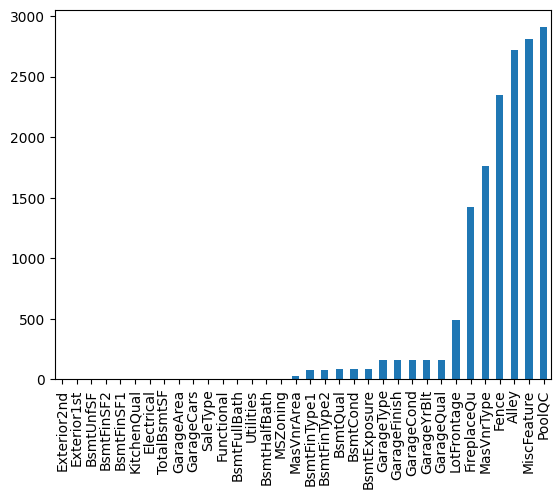

In [24]:
clean_nulls(full_data).plot.bar()

##### 19 attributes have missing values, 5 over 50% of all data. Most of times 

In [25]:
# Drop columns 'MiscFeature', 'Fence', 'PoolQC', 'Id', and 'Alley' because they contain 
# missing values (NaN) in less than 80% of the data, which may not provide meaningful 
# information for the model. The inplace=True parameter modifies the original dataset.
cols_to_drop = ['MiscFeature', 'Fence', 'PoolQC','Alley','MasVnrType','FireplaceQu']
full_data.drop("FireplaceQu",axis=1,inplace=True)
full_data.drop("MasVnrType",axis=1,inplace=True)
full_data.drop("MiscFeature",axis=1,inplace=True)
full_data.drop("Fence",axis=1,inplace=True)
full_data.drop("PoolQC",axis=1,inplace=True)
full_data.drop("Alley",axis=1,inplace=True)



In [26]:
# Count the number of missing (null) values in each row of the combined dataset
nulls_in_rows = dict(full_data.isnull().sum(axis=1))

# Filter rows that have more than 10 missing values
Existednulls = {c: v for c, v in nulls_in_rows.items() if v > 10}

# Display the rows with excessive missing values
Existednulls

{1845: np.int64(11), 2118: np.int64(11)}

In [27]:
numeric_cols = full_data.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    if full_data[col].isna().sum() > 0:
          full_data.fillna({col: full_data[col].median()}, inplace=True)

In [28]:
clean_nulls(full_data)

Exterior2nd       1
Exterior1st       1
KitchenQual       1
Electrical        1
SaleType          1
Utilities         2
Functional        2
MSZoning          4
BsmtFinType1     79
BsmtFinType2     80
BsmtQual         81
BsmtExposure     82
BsmtCond         82
GarageType      157
GarageQual      159
GarageFinish    159
GarageCond      159
dtype: int64

In [29]:
string_null=clean_nulls(full_data).keys()
for col in string_null:
     full_data.fillna({col: full_data[col].mode()[0]}, inplace=True)

In [30]:
clean_nulls(full_data)

Series([], dtype: int64)

In [31]:
y = y.replace([np.inf, -np.inf], np.nan).dropna()


In [32]:
def encode_by_frequency(full_data):
    object_cols = full_data.select_dtypes(include='object').columns
    for col in object_cols:
        freq = full_data[col].value_counts()
        full_data[col] = full_data[col].map(freq)
    return full_data

In [33]:
encode_by_frequency(full_data)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,2267,65.0,8450,2905,1859,2622,2916,2132,2776,...,61,0,0,0,0,0,2,2008,2526,2402
1,20,2267,80.0,9600,2905,1859,2622,2916,85,2776,...,0,0,0,0,0,0,5,2007,2526,2402
2,60,2267,68.0,11250,2905,967,2622,2916,2132,2776,...,42,0,0,0,0,0,9,2008,2526,2402
3,70,2267,60.0,9550,2905,967,2622,2916,510,2776,...,35,272,0,0,0,0,2,2006,2526,190
4,60,2267,84.0,14260,2905,967,2622,2916,85,2776,...,84,0,0,0,0,0,12,2008,2526,2402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,160,460,21.0,1936,2905,1859,2622,2916,2132,2776,...,0,0,0,0,0,0,6,2006,2526,2402
2913,160,460,21.0,1894,2905,1859,2622,2916,2132,2776,...,24,0,0,0,0,0,4,2006,2526,190
2914,20,2267,160.0,20000,2905,1859,2622,2916,2132,2776,...,0,0,0,0,0,0,9,2006,2526,190
2915,85,2267,62.0,10441,2905,1859,2622,2916,2132,2776,...,32,0,0,0,0,700,7,2006,2526,2402


In [34]:
warnings.filterwarnings("ignore")

#### It is apparent that SalePrice doesn't follow normal distribution, so before performing regression it has to be transformed. While log transformation does pretty good job, best fit is unbounded Johnson distribution.

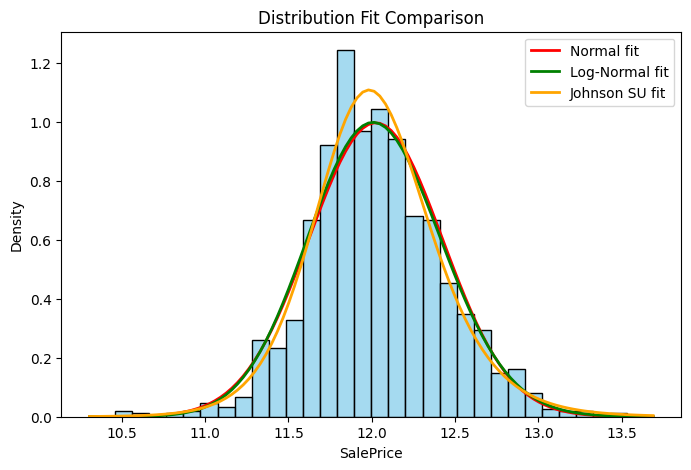

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=False, stat='density', bins=30, color='skyblue')

# Normal
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, y.mean(), y.std())
plt.plot(x, p, 'r', linewidth=2, label='Normal fit')

#  Log-Normal
shape, loc, scale = stats.lognorm.fit(y)
p2 = stats.lognorm.pdf(x, shape, loc, scale)
plt.plot(x, p2, 'g', linewidth=2, label='Log-Normal fit')

#  Johnson SU
params = stats.johnsonsu.fit(y)
p3 = stats.johnsonsu.pdf(x, *params)
plt.plot(x, p3, 'orange', linewidth=2, label='Johnson SU fit')

plt.title('Distribution Fit Comparison')
plt.legend()
plt.show()


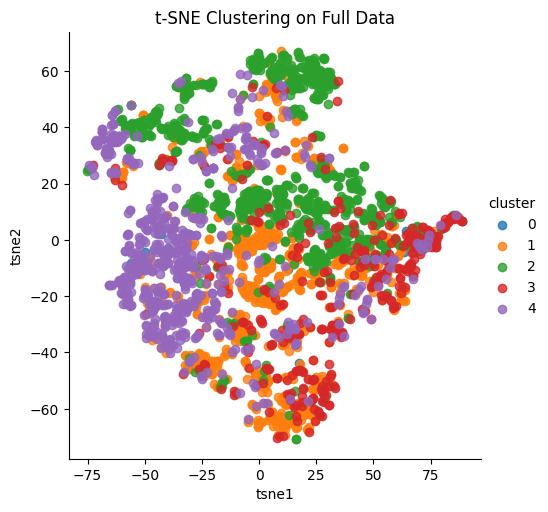

Total explained variance by PCA (30 components): 0.7406316018049408


In [36]:

features = full_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
X = full_data[features]
# Standardize the data
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)


# Apply PCA to reduce dimensionality
pca_model = PCA(n_components=30)
pca_result = pca_model.fit_transform(scaled_X)

#Apply t-SNE for 2D visualization
tsne_model = TSNE(n_components=2, random_state=0, perplexity=20)
tsne_result = tsne_model.fit_transform(X)

# Apply KMeans clustering
kmeans_model = KMeans(n_clusters=5, random_state=0,n_init='auto')
kmeans_model.fit(pca_result)

# Create a DataFrame for visualization
tsne_df = pd.DataFrame({
    'tsne1': tsne_result[:, 0],
    'tsne2': tsne_result[:, 1],
    'cluster': kmeans_model.labels_
})

# Plot the clusters using t-SNE coordinates
sns.lmplot(data=tsne_df, x='tsne1', y='tsne2', hue='cluster', fit_reg=False)
plt.title('t-SNE Clustering on Full Data')
plt.show()

# Print the total explained variance from PCA
print("Total explained variance by PCA (30 components):", np.sum(pca_model.explained_variance_ratio_))

### 2) Outliers

In [37]:
y.shape

(1458,)

count    1458.000000
mean       12.024015
std         0.399713
min        10.460271
25%        11.774720
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Count'>

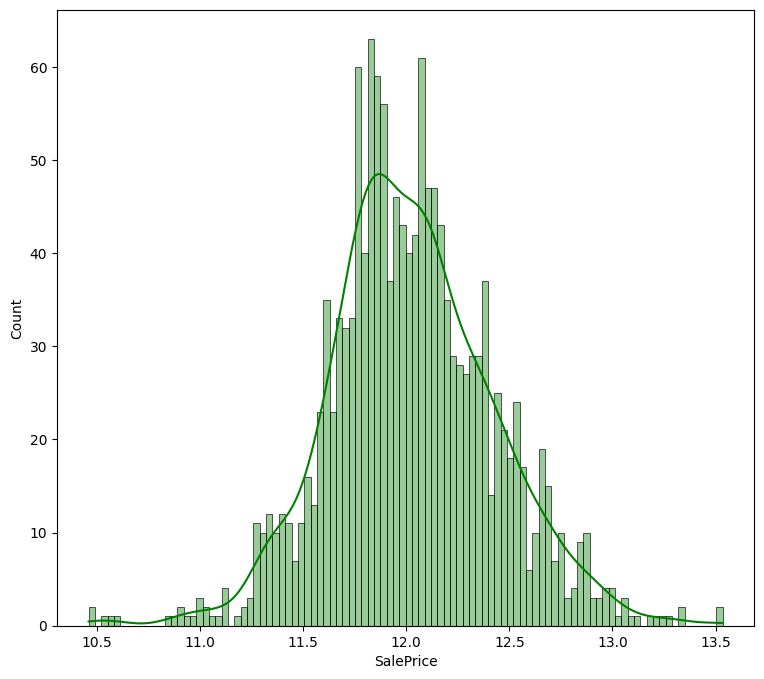

In [38]:
# Print summary statistics for the 'SalePrice' column (count, mean, std, min, quartiles, max)
print(y.describe())

# Create a new figure with a specific size for the plot
plt.figure(figsize=(9, 8))

# Plot a histogram of 'SalePrice' with 100 bins, green color, 40% transparency, and a KDE curve
sns.histplot(y, kde=True, color='g', bins=100, alpha=0.4)


array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'MSZoning'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'Street'}>,
        <Axes: title={'center': 'LotShape'}>,
        <Axes: title={'center': 'LandContour'}>,
        <Axes: title={'center': 'Utilities'}>,
        <Axes: title={'center': 'LotConfig'}>],
       [<Axes: title={'center': 'LandSlope'}>,
        <Axes: title={'center': 'Neighborhood'}>,
        <Axes: title={'center': 'Condition1'}>,
        <Axes: title={'center': 'Condition2'}>,
        <Axes: title={'center': 'BldgType'}>,
        <Axes: title={'center': 'HouseStyle'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'RoofStyle'}>,
        <Axes: title={'center': 'RoofMatl'}>,
  

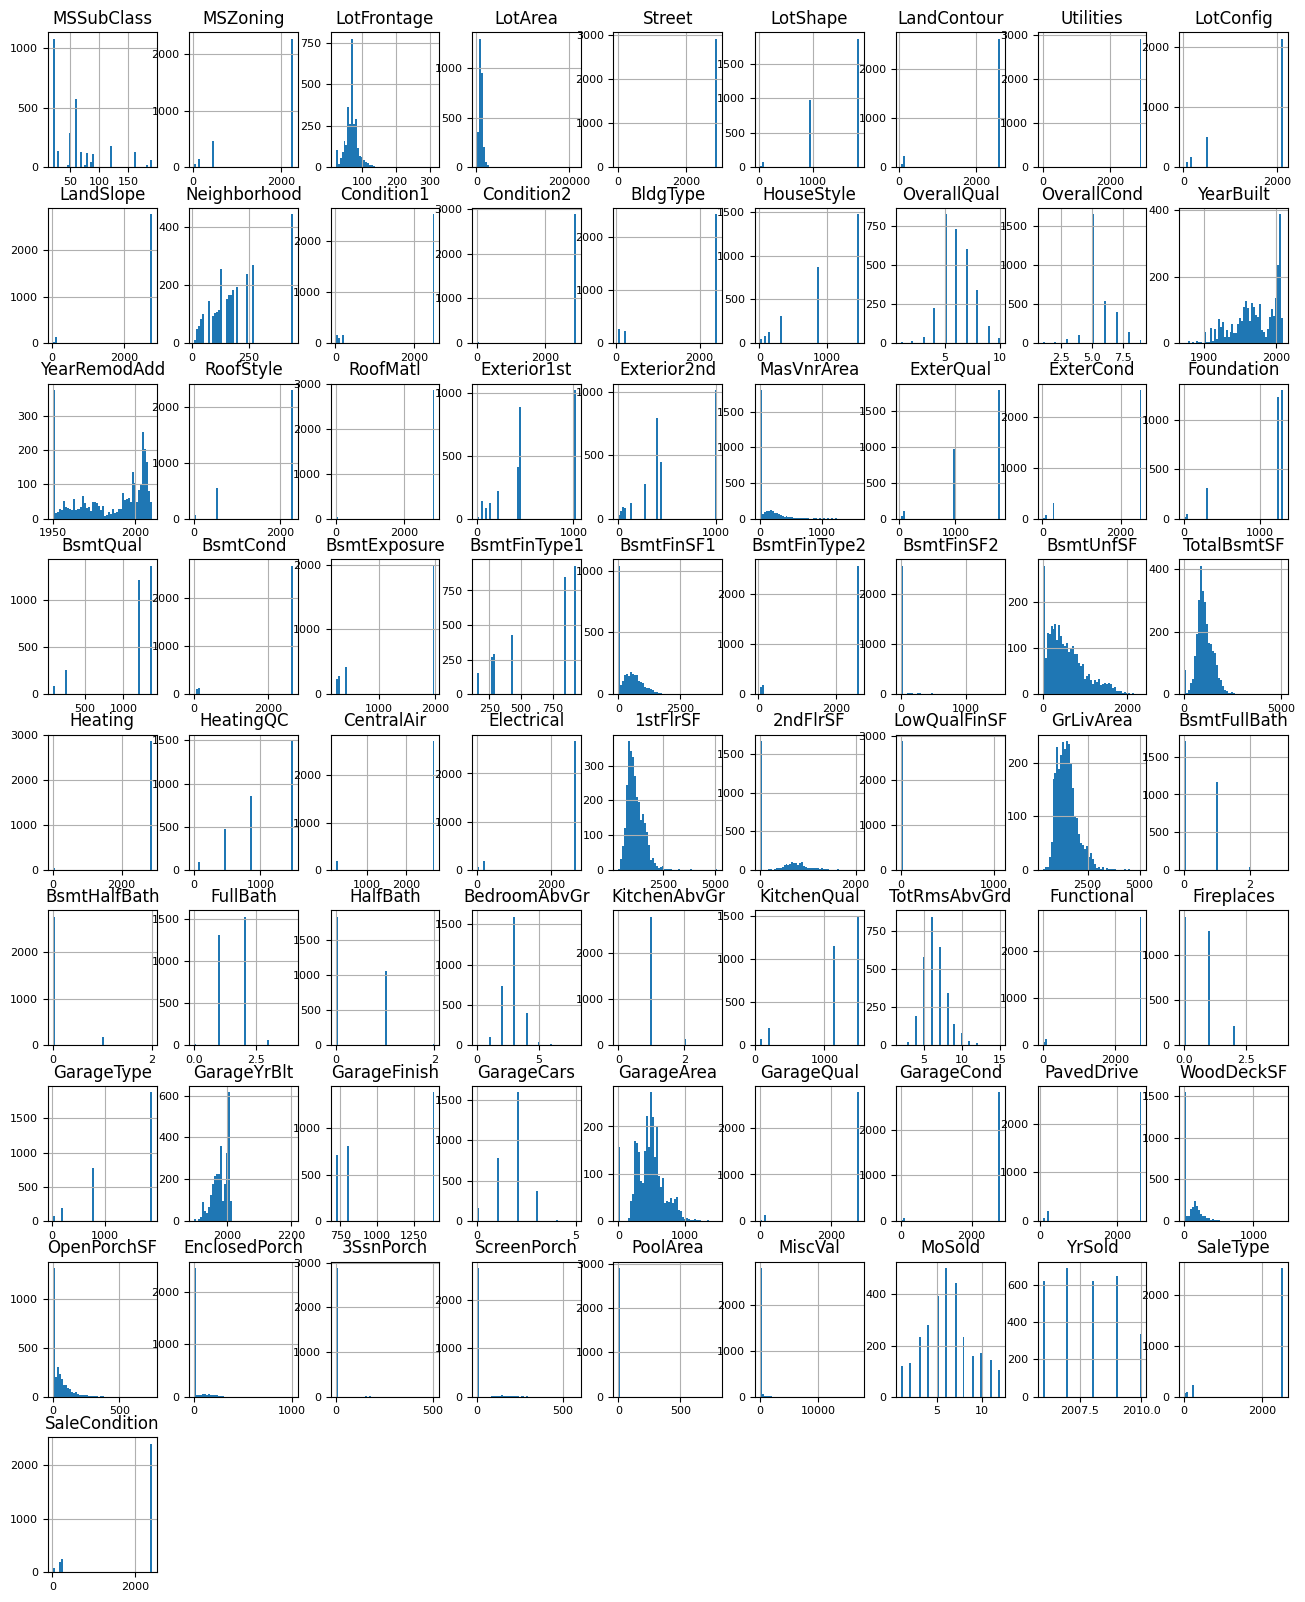

In [39]:
#Now let us plot the distribution for all the featuresa
full_data.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)


In [40]:
def remove_outliers_with_isolation_forest(X, y, contamination=0.1, random_state=42, verbose=True):
    """
    Removes outliers from X and y using IsolationForest.
    
    Parameters:
        X (pd.DataFrame): Training features
        y (pd.Series or np.array): Target values
        contamination (float): Proportion of outliers to remove
        random_state (int): Random seed for reproducibility
        verbose (bool): Whether to print summary info

    Returns:
        X_clean (pd.DataFrame): Cleaned features
        y_clean (pd.Series or np.array): Cleaned target
    """
    assert len(X) == len(y), "X and y must have the same length"
    
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    outliers = iso.fit_predict(X)
    
    mask = outliers == 1  # 1 = inlier, -1 = outlier
    X_clean = X[mask].reset_index(drop=True)
    y_clean = y[mask].reset_index(drop=True)
    
    if verbose:
        n_removed = len(y) - len(y_clean)
        pct = n_removed / len(y) * 100
        print(f"Removed {n_removed} outliers ({pct:.1f}%)")
        print(f"After removal: X shape = {X_clean.shape}, y length = {len(y_clean)}")
    
    return X_clean, y_clean


##### It is apparent that SalePrice doesn't follow normal distribution, so before performing regression it has to be transformed. While log transformation does pretty good job, best fit is unbounded Johnson distribution.

In [41]:
test_normality = lambda x: stats.shapiro(x)[1] < 0.01
normal = full_data.apply(test_normality)
print("All columns are normally distributed:", not normal.any())

All columns are normally distributed: False


In [42]:
constant_cols = [col for col in full_data.columns if full_data[col].nunique() == 1]
print("Constant columns:", constant_cols)

Constant columns: []


In [43]:
from scipy.stats import boxcox, boxcox_normmax, skew
exclude_cols = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold']
numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numerics2 = [col for col in full_data.columns if full_data[col].dtype in numeric_dtypes]
skew_features = full_data[numerics2].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skew_features[skew_features > 0.5]
skew_index = [col for col in high_skew.index if col not in exclude_cols]
for col in skew_index:
    if (full_data[col] > -1).all():
        try:
            lambda_val = boxcox_normmax(full_data[col] + 1)
            full_data[col] = boxcox(full_data[col] + 1, lambda_val)
        except Exception as e:
            print(f"Skipping {col}: {e}")

Skipping LotArea: The algorithm terminated without finding a valid bracket. Consider trying different initial points.
Skipping 1stFlrSF: The algorithm terminated without finding a valid bracket. Consider trying different initial points.


### 3)Feature Extraction
######
###### What is Feature Extraction?
It is the process of creating new columns (features) from the original ones in order to:
- Reveal hidden relationships in the data.
- Help the model understand the data more deeply.
- Improve the accuracy of predicting the sale price.


In [44]:
# Total living area (above ground + basement)
full_data['TotalLivingArea'] = full_data['GrLivArea'] + full_data['TotalBsmtSF']

# Total number of bathrooms (weighted)
full_data['TotalBath'] = full_data['FullBath'] + (0.5 * full_data['HalfBath']) + \
                    full_data['BsmtFullBath'] + (0.5 * full_data['BsmtHalfBath'])

# Total porch area
full_data['TotalPorchSF'] = full_data['OpenPorchSF'] + full_data['EnclosedPorch'] + \
                       full_data['3SsnPorch'] + full_data['ScreenPorch']

# Total finished basement area
full_data['TotalBsmtFinishedSF'] = full_data['BsmtFinSF1'] + full_data['BsmtFinSF2']

In [45]:
# Age of the house at time of sale
full_data['HouseAge'] = full_data['YrSold'] - full_data['YearBuilt']

# Years since last remodel
full_data['YearsSinceRemodel'] = full_data['YrSold'] - full_data['YearRemodAdd']

In [46]:
# Was the house remodeled?
full_data['IsRemodeled'] = (full_data['YearBuilt'] != full_data['YearRemodAdd']).astype(int)

# Was the garage built with the house?
full_data['GarageBuiltWithHouse'] = (full_data['YearBuilt'] == full_data['GarageYrBlt']).astype(int)

In [47]:
# Interactions
full_data['QualGrLivArea'] = full_data['OverallQual'] * full_data['GrLivArea']  
full_data['QualTotalSF'] = full_data['OverallQual'] * (full_data['1stFlrSF'] + full_data['2ndFlrSF'])  
full_data['AgeQual'] = full_data['HouseAge'] * full_data['OverallQual']  

In [48]:
#Domain Features 
full_data['TotalSF'] = full_data['TotalBsmtSF'] + full_data['1stFlrSF'] + full_data['2ndFlrSF'] + full_data['GrLivArea']  
full_data['HasPool'] = (full_data['PoolArea'] > 0).astype(int)  
full_data['HasFireplace'] = (full_data['Fireplaces'] > 0).astype(int) 
full_data['HasBsmt'] = (full_data['TotalBsmtSF'] > 0).astype(int)  
full_data['GarageAge'] = full_data['YrSold'] - full_data['GarageYrBlt'].fillna(0)  

In [49]:
full_data['RoomsPerSF'] = full_data['TotRmsAbvGrd'] / (full_data['TotalSF'] + 1)  
full_data['HasLuxury'] = ((full_data['OverallQual'] >= 8) & (full_data['TotalSF'] > 2000)).astype(int)   

In [50]:
luxury_neigh = ['NridgHt', 'NoRidge', 'CollgCr'] 
full_data['NeighLux'] = full_data['Neighborhood'].isin(luxury_neigh).astype(int)
print("Added 3 domain features!")

Added 3 domain features!


In [51]:
full_data['HouseAgeBin'] = pd.cut(full_data['HouseAge'], bins=[-1, 0, 10, 30, 50, 100], labels=[-1,0,1,2,3], right=True)  
full_data['OverallQualBin'] = pd.cut(full_data['OverallQual'], bins=5, labels=[0,1,2,3,4], right=True)
full_data['HouseAgeBin'] = full_data['HouseAgeBin'].fillna(3).astype(int)
full_data['OverallQualBin'] = full_data['OverallQualBin'].fillna(4).astype(int)  


In [52]:
full_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,TotalSF,HasPool,HasFireplace,HasBsmt,GarageAge,RoomsPerSF,HasLuxury,NeighLux,HouseAgeBin,OverallQualBin
0,6.499672,2267,16.311604,8450,2905,1859,2622,2916,2132,2776,...,2308.660781,0,0,1,5.0,0.000979,0,0,0,3
1,4.249693,2267,18.466370,9600,2905,1859,2622,2916,85,2776,...,1858.110051,0,1,1,31.0,0.001074,0,0,2,2
2,6.499672,2267,16.758974,11250,2905,967,2622,2916,2132,2776,...,2414.873952,0,1,1,7.0,0.000826,0,0,0,3
3,6.862540,2267,15.545035,9550,2905,967,2622,2916,510,2776,...,2249.327669,0,1,1,8.0,0.000950,0,0,3,3
4,6.499672,2267,19.009682,14260,2905,967,2622,2916,85,2776,...,2966.805418,0,1,1,8.0,0.000800,1,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,9.030082,460,8.106495,1936,2905,1859,2622,2916,2132,2776,...,1482.722684,0,0,1,27.0,0.001237,0,0,2,1
2913,9.030082,460,8.106495,1894,2905,1859,2622,2916,2132,2776,...,1482.722684,0,0,1,36.0,0.001346,0,0,2,1
2914,4.249693,2267,27.745340,20000,2905,1859,2622,2916,2132,2776,...,1804.538549,0,1,1,46.0,0.001184,0,0,2,2
2915,7.337374,2267,15.854949,10441,2905,1859,2622,2916,2132,2776,...,1420.196817,0,0,1,27.0,0.001405,0,0,1,2


In [53]:
full_data.shape

(2917, 94)

In [54]:
n_train = len(y)
X = full_data.iloc[:n_train, :]
X_sub = full_data.iloc[n_train:, :]

X, y = remove_outliers_with_isolation_forest(X, y, contamination=0.1)
X.shape, y.shape, X_sub.shape

Removed 146 outliers (10.0%)
After removal: X shape = (1312, 94), y length = 1312


((1312, 94), (1312,), (1459, 94))

In [55]:
X_sub = X_sub.reindex(columns=X.columns, fill_value=0)


In [56]:
def drop_quasi_constant_features(df_train, df_test, threshold=0.99):
    cols_to_drop = []
    for col in df_train.columns:
        top_freq = df_train[col].value_counts(normalize=True).max()
        if top_freq >= threshold:
            cols_to_drop.append(col)
    
    print(f"Dropping {len(cols_to_drop)} quasi-constant columns")
    return df_train.drop(columns=cols_to_drop), df_test.drop(columns=cols_to_drop)

X, X_sub = drop_quasi_constant_features(X, X_sub, threshold=0.99)

Dropping 8 quasi-constant columns


In [57]:
print(X.columns.equals(X_sub.columns)) #True


True


In [58]:
#Splitting data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44, shuffle =True)

#Splitted Data
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (984, 86)
X_test shape is  (328, 86)
y_train shape is  (984,)
y_test shape is  (328,)


## 4)Building Model

### Fit Model

In [59]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
# Tuning XGBoost
def xgb_tune(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 3000, 5000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'max_depth': trial.suggest_int('max_depth', 4, 6),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0001, 0.01),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0001, 0.01)
    }
    model = XGBRegressor(**params, random_state=42, objective='reg:squarederror')
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_log_error')
    return scores.mean()

In [60]:
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_tune, n_trials=30)
best_xgb = study_xgb.best_params
xgboost = XGBRegressor(**best_xgb, random_state=42, objective='reg:squarederror')


In [61]:
# LGBM 
lightgbm = LGBMRegressor(objective='regression', num_leaves=4, learning_rate=0.01, n_estimators=5000,
                         max_bin=200, bagging_fraction=0.75, bagging_freq=5, bagging_seed=7,
                         feature_fraction=0.2, feature_fraction_seed=7, verbose=-1, random_state=42)


In [62]:
alphas_alt = [14.5, 14.6, 14.7, 14.8, 14.9, 15, 15.1, 15.2, 15.3, 15.4, 15.5,15.4,15.3]
alphas2 = [5e-05, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009]
e_alphas = [0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007,0.0008,0.0009]
e_l1ratio = [0.8, 0.85, 0.9, 0.95, 0.99, 1]
kfolds = KFold(n_splits=10, shuffle=True, random_state=42)

In [63]:
gbr = GradientBoostingRegressor(n_estimators=3500, learning_rate=0.05, max_depth=5, max_features='sqrt',
                                min_samples_leaf=15, min_samples_split=10, loss='huber', random_state=42)
catboost = CatBoostRegressor(iterations=5000, learning_rate=0.02, depth=4, eval_metric='RMSE', early_stopping_rounds=50,
                             random_seed=42, verbose=0)
ridge = make_pipeline(RobustScaler(), RidgeCV(alphas=alphas_alt, cv=kfolds))
lasso = make_pipeline(RobustScaler(), LassoCV(max_iter=10000000, alphas=alphas2, random_state=42, cv=kfolds))  # int fixed
elasticnet = make_pipeline(RobustScaler(), ElasticNetCV(max_iter=10000000, alphas=e_alphas, cv=kfolds, l1_ratio=e_l1ratio))  # int fixed
svr = make_pipeline(RobustScaler(), SVR(C=30, epsilon=0.008, gamma=0.0003))


### Model testing

In [64]:
from sklearn.ensemble import StackingRegressor

stack_gen = StackingRegressor(
    estimators=[
        ('ridge', ridge),
        ('lasso', lasso),
        ('elasticnet', elasticnet),
        ('gbr', gbr),
        ('xgboost', xgboost),
        ('lightgbm', lightgbm),
        ('svr', svr),
        ('catboost', catboost)
    ],
    final_estimator=catboost,       
    cv=10,                           
    n_jobs=-1,                       
    passthrough=True                 
)

stack_gen.fit(X_train, y_train)

StackingRegressor(cv=10,
                  estimators=[('ridge',
                               Pipeline(steps=[('robustscaler', RobustScaler()),
                                               ('ridgecv',
                                                RidgeCV(alphas=[14.5, 14.6,
                                                                14.7, 14.8,
                                                                14.9, 15, 15.1,
                                                                15.2, 15.3,
                                                                15.4, 15.5,
                                                                15.4, 15.3],
                                                        cv=KFold(n_splits=10, random_state=42, shuffle=True)))])),
                              ('lasso',
                               Pipeline(steps=[('robustscaler', RobustScaler()),
                                               ('lassocv',
                                                LassoCV(alphas=[5e-05, 0.0001,
                                                                0.0002, 0.0003...
                                             n_estimators=5000, num_leaves=4,
                                             objective='regression',
                                             random_state=42, verbose=-1)),
                              ('svr',
                               Pipeline(steps=[('robustscaler', RobustScaler()),
                                               ('svr',
                                                SVR(C=30, epsilon=0.008,
                                                    gamma=0.0003))])),
                              ('catboost',
                               <catboost.core.CatBoostRegressor object at 0x7d7fa968e150>)],
                  final_estimator=<catboost.core.CatBoostRegressor object at 0x7d7fa968e150>,
                  n_jobs=-1, passthrough=True)

In [67]:
y_pred_test = stack_gen.predict(X_test)
    # Efficiency
print("RMSE:", root_mean_squared_error(y_test, y_pred_test))
print("RMSLE:", np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred_test, 1e-9))))
print("R² Score:", r2_score(y_test, y_pred_test))

RMSE: 0.11464692714642646
RMSLE: 0.008880572096279665
R² Score: 0.8851792931095465


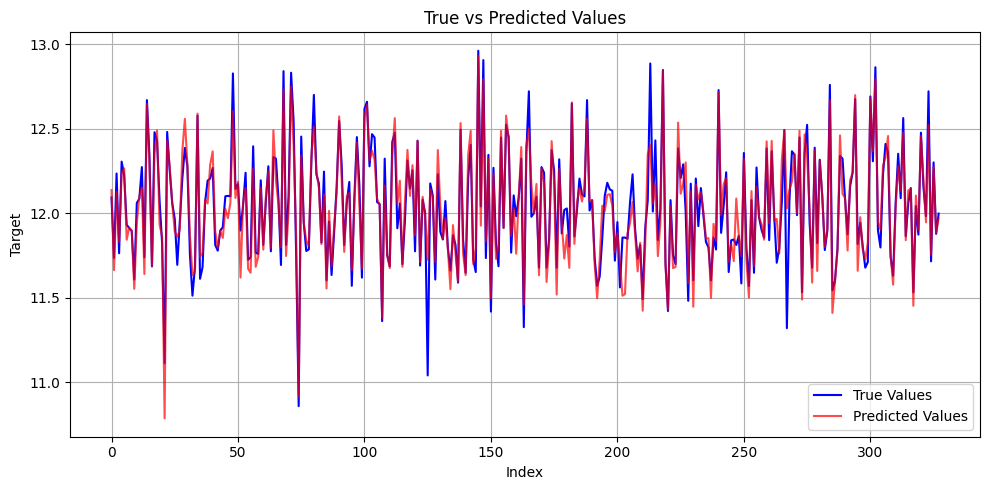

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='True Values', color='blue')
plt.plot(y_pred_test, label='Predicted Values', color='red', alpha=0.7)
plt.title('True vs Predicted Values')
plt.xlabel('Index')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


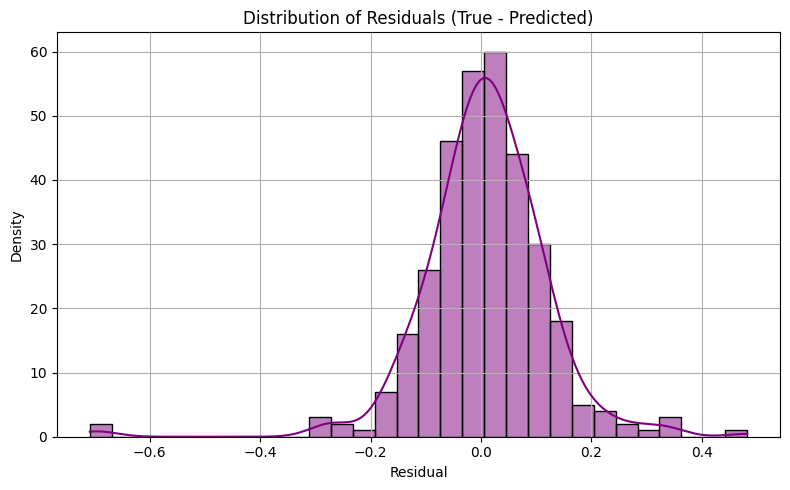

In [69]:
residuals = y_test.values - y_pred_test
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Distribution of Residuals (True - Predicted)')
plt.xlabel('Residual')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

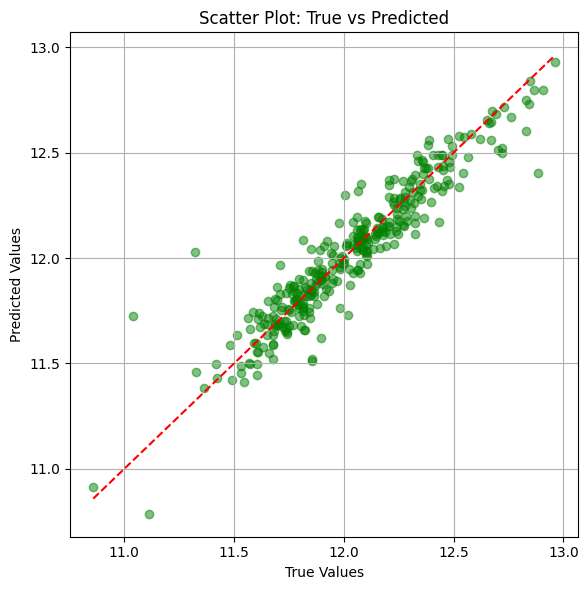

In [70]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot: True vs Predicted')
plt.grid(True)
plt.tight_layout()


### final model

In [71]:
# Final model Stacking X,Y we will use all data
Final_stack_gen = StackingRegressor(
    estimators=[
        ('ridge', ridge),
        ('lasso', lasso),
        ('elasticnet', elasticnet),
        ('gbr', gbr),
        ('xgboost', xgboost),
        ('lightgbm', lightgbm),
        ('svr', svr),
        ('catboost', catboost)
    ],
    final_estimator=catboost,       
    cv=10,                           
    n_jobs=-1,  
    passthrough=True               
)

Final_stack_gen.fit(X, y)

StackingRegressor(cv=10,
                  estimators=[('ridge',
                               Pipeline(steps=[('robustscaler', RobustScaler()),
                                               ('ridgecv',
                                                RidgeCV(alphas=[14.5, 14.6,
                                                                14.7, 14.8,
                                                                14.9, 15, 15.1,
                                                                15.2, 15.3,
                                                                15.4, 15.5,
                                                                15.4, 15.3],
                                                        cv=KFold(n_splits=10, random_state=42, shuffle=True)))])),
                              ('lasso',
                               Pipeline(steps=[('robustscaler', RobustScaler()),
                                               ('lassocv',
                                                LassoCV(alphas=[5e-05, 0.0001,
                                                                0.0002, 0.0003...
                                             n_estimators=5000, num_leaves=4,
                                             objective='regression',
                                             random_state=42, verbose=-1)),
                              ('svr',
                               Pipeline(steps=[('robustscaler', RobustScaler()),
                                               ('svr',
                                                SVR(C=30, epsilon=0.008,
                                                    gamma=0.0003))])),
                              ('catboost',
                               <catboost.core.CatBoostRegressor object at 0x7d7fa968e150>)],
                  final_estimator=<catboost.core.CatBoostRegressor object at 0x7d7fa968e150>,
                  n_jobs=-1, passthrough=True)

In [72]:
print('Predict submission')
submission = pd.read_csv(r'/kaggle/input/house-prices/sample_submission.csv')
submission['SalePrice'] =np.expm1((Final_stack_gen.predict(X_sub)))
submission.to_csv('/kaggle/working/submission1.csv', index=False)
submission.head()

Predict submission


,Id,SalePrice
0,1461,125568.197393
1,1462,163254.233916
2,1463,182951.886592
3,1464,191412.751337
4,1465,176363.081812
